# ASAP7 Multi-Stage Topology Cache Inspector
Verify that multi-stage topology extraction is working correctly for ASAP7 cells

**Purpose**: Check stage-aware topology caches for multi-stage format including:
- `num_stages` (number of stages)
- `stages` list with per-stage transistor/gate info
- `intermediate_gate_widths` with per-gate width sums
- Edge attributes with 5-dim one-hot stage encoding

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# Set style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## 1. Load ASAP7 Stage-Aware Topology Cache

In [ ]:
# Load ASAP7 stage-aware cache
stage_aware_cache_path = "/home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/stage_aware_topology_cache_asap7sc7p5t_28_L.pth"

print(f"Loading ASAP7 stage-aware cache from: {stage_aware_cache_path}")
stage_aware_cache = torch.load(stage_aware_cache_path, weights_only=False)

print(f"\nLoaded {len(stage_aware_cache)} cells")
print(f"\nCell names and multi-stage info (first 20):")
for i, cell_name in enumerate(sorted(stage_aware_cache.keys())[:20]):
    cell_data = stage_aware_cache[cell_name]
    output_nodes = cell_data['output_nodes']
    print(f"  [{i:2d}] {cell_name:<40s} Outputs: {output_nodes}")
    
    # Check each output's pull-up and pull-down stages
    for output_name in output_nodes:
        if output_name in cell_data['output_topologies']:
            output_topo = cell_data['output_topologies'][output_name]
            
            # Check pull-up
            pull_up = output_topo['pull_up']
            stage_info_up = pull_up.get('stage_info', {})
            num_stages_up = stage_info_up.get('num_stages', 0)
            # Fallback to legacy format
            if num_stages_up == 0 and 'stage_type' in stage_info_up:
                num_stages_up = 2 if stage_info_up['stage_type'] == 'two_stage' else 1
            
            # Check pull-down
            pull_down = output_topo['pull_down']
            stage_info_down = pull_down.get('stage_info', {})
            num_stages_down = stage_info_down.get('num_stages', 0)
            # Fallback to legacy format
            if num_stages_down == 0 and 'stage_type' in stage_info_down:
                num_stages_down = 2 if stage_info_down['stage_type'] == 'two_stage' else 1
            
            print(f"       {output_name}: Pull-up={num_stages_up}-stage, Pull-down={num_stages_down}-stage")

Loading ASAP7 stage-aware cache from: /home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/stage_aware_topology_cache_asap7sc7p5t_28_L.pth

Loaded 160 cells

Cell names and multi-stage info (first 20):
  [ 0] AND2x2_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 1] AND2x4_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 2] AND2x6_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 3] AND3x1_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 4] AND3x2_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 5] AND3x4_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 6] AND4x1_ASAP7_75t_L                       Outputs: ['Y']
       Y: Pull-up=2-stage, Pull-down=2-stage
  [ 7] AND4x2_AS

## 2. Verify Multi-Stage Cache Structure

In [ ]:
# Select a cell to inspect in detail (XOR/XNOR cells are good for multi-stage testing)
# Look for complex cells with more stages
complex_cells = []
for cell_name in stage_aware_cache.keys():
    for keyword in ['XOR', 'XNOR', 'AOI', 'OAI', 'MUX']:
        if keyword in cell_name.upper():
            complex_cells.append(cell_name)
            break

if complex_cells:
    cell_name = sorted(complex_cells)[0]
else:
    cell_name = sorted(stage_aware_cache.keys())[0]

cell_cache = stage_aware_cache[cell_name]

print(f"Inspecting ASAP7 multi-stage cell: {cell_name}")
print("=" * 80)

# Get first output
output_name = cell_cache['output_nodes'][0]
output_topo = cell_cache['output_topologies'][output_name]

print(f"\nOutput: {output_name}")

# Detailed Pull-up inspection
print(f"\n{'='*40}")
print(f"PULL-UP PATH STRUCTURE")
print(f"{'='*40}")
pull_up = output_topo['pull_up']
for key, value in pull_up.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key:25s}: Tensor {list(value.shape)} dtype={value.dtype}")
    elif isinstance(value, dict):
        print(f"  {key:25s}: Dict with keys {list(value.keys())}")
    elif isinstance(value, list):
        if len(value) <= 10:
            print(f"  {key:25s}: {value}")
        else:
            print(f"  {key:25s}: List with {len(value)} items")
    else:
        print(f"  {key:25s}: {type(value).__name__} = {value}")

# Detailed Pull-down inspection
print(f"\n{'='*40}")
print(f"PULL-DOWN PATH STRUCTURE")
print(f"{'='*40}")
pull_down = output_topo['pull_down']
for key, value in pull_down.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key:25s}: Tensor {list(value.shape)} dtype={value.dtype}")
    elif isinstance(value, dict):
        print(f"  {key:25s}: Dict with keys {list(value.keys())}")
    elif isinstance(value, list):
        if len(value) <= 10:
            print(f"  {key:25s}: {value}")
        else:
            print(f"  {key:25s}: List with {len(value)} items")
    else:
        print(f"  {key:25s}: {type(value).__name__} = {value}")

Inspecting ASAP7 multi-stage cell: AOI211x1_ASAP7_75t_L

Output: Y

PULL-UP PATH STRUCTURE
  all_nodes                : ['VDD', 'VSS', 'Y', 'MM21', 'MM6', 'MM7', 'MM0']
  edge_index               : Tensor [2, 12] dtype=torch.int64
  edge_attr                : Tensor [12, 5] dtype=torch.float32
  adjacency_matrix         : Tensor [7, 7] dtype=torch.float32
  stage_info               : Dict with keys ['num_stages', 'stage_type', 'stages', 'all_transistors', 'intermediate_gates', 'all_intermediate_nodes']
  num_nodes                : int = 7
  num_edges                : int = 12

PULL-DOWN PATH STRUCTURE
  all_nodes                : ['VDD', 'VSS', 'Y', 'MM20', 'MM3', 'MM5', 'MM4']
  edge_index               : Tensor [2, 7] dtype=torch.int64
  edge_attr                : Tensor [7, 5] dtype=torch.float32
  adjacency_matrix         : Tensor [7, 7] dtype=torch.float32
  stage_info               : Dict with keys ['num_stages', 'stage_type', 'stages', 'all_transistors', 'intermediate_gates', 'a

## 3. Inspect Multi-Stage Stage Info Details

In [ ]:
# Detailed stage_info inspection
def print_stage_info(stage_info, path_type):
    print(f"\n{'='*60}")
    print(f"{path_type} STAGE INFO DETAILS")
    print(f"{'='*60}")
    
    # Multi-stage format
    num_stages = stage_info.get('num_stages', 0)
    if num_stages > 0:
        print(f"\n  Number of stages: {num_stages}")
    
    # Legacy format fallback
    if 'stage_type' in stage_info:
        print(f"  Stage type (legacy): {stage_info['stage_type']}")
        if num_stages == 0:
            num_stages = 2 if stage_info['stage_type'] == 'two_stage' else 1
            print(f"  Inferred num_stages: {num_stages}")
    
    # Intermediate gates
    intermediate_gates = stage_info.get('intermediate_gates', [])
    print(f"\n  Intermediate gates ({len(intermediate_gates)}):")
    for gate in intermediate_gates:
        print(f"      - {gate}")
    
    # Stages list (multi-stage format)
    stages = stage_info.get('stages', [])
    if stages:
        print(f"\n  Stages list ({len(stages)} stages):")
        for i, stage in enumerate(stages):
            print(f"\n    Stage {i+1}:")
            transistors = stage.get('transistors', [])
            print(f"      Transistors ({len(transistors)}): {transistors}")
            gates = stage.get('gates', [])
            print(f"      Gates ({len(gates)}): {gates}")
    else:
        # Legacy format (stage1_transistors, stage2_transistors)
        print(f"\n  Legacy stage format:")
        for key in sorted(stage_info.keys()):
            if 'transistors' in key.lower():
                print(f"    {key}: {stage_info[key]}")

# Print for both paths
print_stage_info(pull_up.get('stage_info', {}), 'PULL-UP')
print_stage_info(pull_down.get('stage_info', {}), 'PULL-DOWN')


PULL-UP STAGE INFO DETAILS

  Number of stages: 1
  Stage type (legacy): one_stage

  Intermediate gates (0):

  Stages list (1 stages):

    Stage 1:
      Transistors (4): ['MM21', 'MM6', 'MM7', 'MM0']
      Gates (0): []

PULL-DOWN STAGE INFO DETAILS

  Number of stages: 1
  Stage type (legacy): one_stage

  Intermediate gates (0):

  Stages list (1 stages):

    Stage 1:
      Transistors (4): ['MM20', 'MM3', 'MM5', 'MM4']
      Gates (0): []


## 4. Verify Intermediate Gate Widths (Per-Gate)

In [ ]:
# Check intermediate_gate_widths for per-gate width sums
# Note: ASAP7 uses runtime fallback from transistor_info, so widths might not be precomputed

def check_intermediate_gate_widths(path_data, path_type):
    print(f"\n{'='*60}")
    print(f"{path_type} INTERMEDIATE GATE WIDTHS")
    print(f"{'='*60}")
    
    stage_info = path_data.get('stage_info', {})
    intermediate_gates = stage_info.get('intermediate_gates', [])
    intermediate_gate_widths = stage_info.get('intermediate_gate_widths', {})
    
    if not intermediate_gates:
        print("  No intermediate gates (single-stage cell)")
        return
    
    print(f"\n  Intermediate gates: {intermediate_gates}")
    print(f"  Width dictionary: {intermediate_gate_widths}")
    
    if intermediate_gate_widths:
        widths = list(intermediate_gate_widths.values())
        all_same = len(set(widths)) == 1
        
        print(f"\n  Width values:")
        for gate, width in intermediate_gate_widths.items():
            print(f"      {gate}: {width:.4f} um")
        
        if all_same and len(widths) > 1:
            print(f"\n  WARNING: All gates have same width ({widths[0]:.4f})")
            print(f"           This might indicate incorrect total-width assignment!")
        else:
            print(f"\n  Per-gate widths: VERIFIED (widths differ per gate)")
    else:
        print(f"\n  NOTE: No precomputed intermediate_gate_widths in stage_info.")
        print(f"        ASAP7 uses runtime fallback from transistor_info.")
        print(f"        This is expected behavior for ASAP7 caches.")

# Check for both paths
check_intermediate_gate_widths(pull_up, 'PULL-UP')
check_intermediate_gate_widths(pull_down, 'PULL-DOWN')


PULL-UP INTERMEDIATE GATE WIDTHS
  No intermediate gates (single-stage cell)

PULL-DOWN INTERMEDIATE GATE WIDTHS
  No intermediate gates (single-stage cell)


## 5. Verify Transistor Info for Runtime Width Calculation

In [ ]:
# For ASAP7, intermediate gate widths are computed at runtime from transistor_info
# Let's verify the transistor_info structure

# Load full graph cache to check transistor_info
full_graph_cache_path = "/home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/cell_topology_cache_asap7sc7p5t_28_L.pth"

print(f"Loading ASAP7 full graph cache from: {full_graph_cache_path}")
full_graph_cache = torch.load(full_graph_cache_path, weights_only=False)

print(f"\nLoaded {len(full_graph_cache)} cells")

# Check transistor_info structure for a complex cell
if complex_cells:
    check_cell = sorted(complex_cells)[0]
else:
    check_cell = sorted(full_graph_cache.keys())[0]

print(f"\nChecking transistor_info for: {check_cell}")
print("=" * 60)

cell_data = full_graph_cache[check_cell]
transistor_info = cell_data.get('transistor_info', {})

print(f"\nTransistor info ({len(transistor_info)} transistors):")
for trans_name, trans_data in transistor_info.items():
    print(f"  {trans_name}:")
    for key, value in trans_data.items():
        print(f"      {key}: {value}")

# Verify gate field exists (needed for runtime width calculation)
print(f"\n" + "=" * 60)
print("Gate-to-transistor mapping (for runtime width calculation):")
gate_to_transistors = {}
for trans_name, trans_data in transistor_info.items():
    gate = trans_data.get('gate', 'unknown')
    if gate not in gate_to_transistors:
        gate_to_transistors[gate] = []
    gate_to_transistors[gate].append((trans_name, trans_data.get('width', 0)))

for gate, trans_list in gate_to_transistors.items():
    total_width = sum(w for _, w in trans_list)
    print(f"  {gate}: {len(trans_list)} transistors, total width = {total_width:.4f}")
    for trans_name, width in trans_list:
        print(f"      {trans_name}: {width:.4f}")

Loading ASAP7 full graph cache from: /home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/cell_topology_cache_asap7sc7p5t_28_L.pth

Loaded 160 cells

Checking transistor_info for: AOI211x1_ASAP7_75t_L

Transistor info (8 transistors):
  MM20:
      type: 1.0
      width: 0.081
      gate: C
      source: VSS
      drain: Y
  MM3:
      type: 1.0
      width: 0.081
      gate: B
      source: VSS
      drain: Y
  MM4:
      type: 1.0
      width: 0.081
      gate: A2
      source: net32
      drain: Y
  MM5:
      type: 1.0
      width: 0.081
      gate: A1
      source: VSS
      drain: net32
  MM21:
      type: -1.0
      width: 0.162
      gate: A2
      source: VDD
      drain: net17
  MM0:
      type: -1.0
      width: 0.162
      gate: A1
      source: VDD
      drain: net17
  MM6:
      type: -1.0
      width: 0.162
      gate: B
      source: net17
      drain: net34
  MM7:
      type: -1.0
      width: 0.162
      gate: C
      source: net34
      drai

## 6. Verify Edge Attribute Dimensions (5-dim One-Hot)

In [ ]:
# Check edge_attr dimensions for 5-dimensional one-hot encoding
def check_edge_attr(path_data, path_type):
    print(f"\n{'='*60}")
    print(f"{path_type} EDGE ATTRIBUTE ANALYSIS")
    print(f"{'='*60}")
    
    edge_attr = path_data.get('edge_attr', None)
    
    if edge_attr is None:
        print("  No edge_attr found!")
        return
    
    print(f"  Shape: {list(edge_attr.shape)}")
    print(f"  Expected: [num_edges, 5] for 5-dim one-hot stage encoding")
    print(f"            [num_edges, 3] for legacy one_stage/two_stage format")
    
    num_edges, num_features = edge_attr.shape
    
    if num_features == 5:
        print(f"\n  5-dim one-hot encoding: VERIFIED (multi-stage format)")
        print(f"  Stage encoding: [stage1, stage2, stage3, stage4, stage5+]")
        
        # Count edges per stage
        stage_counts = [0, 0, 0, 0, 0]
        for edge in edge_attr:
            stage_idx = torch.argmax(edge).item()
            stage_counts[stage_idx] += 1
        
        print(f"\n  Edges per stage:")
        for i, count in enumerate(stage_counts):
            if count > 0:
                stage_label = f"Stage {i+1}" if i < 4 else "Stage 5+"
                print(f"      {stage_label}: {count} edges")
    elif num_features == 3:
        print(f"\n  3-dim encoding detected (legacy one_stage/two_stage format)")
        print(f"  Edge encoding: [in_first_stage, in_second_stage, connects_stages]")
        
        # Count edge types
        edge_types = {'first_stage': 0, 'second_stage': 0, 'cross_stage': 0}
        for edge in edge_attr:
            if edge[0] > 0:
                edge_types['first_stage'] += 1
            if edge[1] > 0:
                edge_types['second_stage'] += 1
            if edge[2] > 0:
                edge_types['cross_stage'] += 1
        
        print(f"\n  Edge type counts:")
        for etype, count in edge_types.items():
            if count > 0:
                print(f"      {etype}: {count}")
    else:
        print(f"\n  UNEXPECTED dimension: {num_features}")

# Check for both paths
check_edge_attr(pull_up, 'PULL-UP')
check_edge_attr(pull_down, 'PULL-DOWN')


PULL-UP EDGE ATTRIBUTE ANALYSIS
  Shape: [12, 5]
  Expected: [num_edges, 5] for 5-dim one-hot stage encoding
            [num_edges, 3] for legacy one_stage/two_stage format

  5-dim one-hot encoding: VERIFIED (multi-stage format)
  Stage encoding: [stage1, stage2, stage3, stage4, stage5+]

  Edges per stage:
      Stage 1: 12 edges

PULL-DOWN EDGE ATTRIBUTE ANALYSIS
  Shape: [7, 5]
  Expected: [num_edges, 5] for 5-dim one-hot stage encoding
            [num_edges, 3] for legacy one_stage/two_stage format

  5-dim one-hot encoding: VERIFIED (multi-stage format)
  Stage encoding: [stage1, stage2, stage3, stage4, stage5+]

  Edges per stage:
      Stage 1: 7 edges


## 7. Stage Distribution Across All Cells

In [ ]:
# Analyze stage distribution across all cells
pull_up_stages = []
pull_down_stages = []
cells_with_many_stages = []

for cell_name, cell_data in stage_aware_cache.items():
    for output_name in cell_data['output_nodes']:
        if output_name in cell_data['output_topologies']:
            output_topo = cell_data['output_topologies'][output_name]
            
            # Pull-up
            stage_info_up = output_topo['pull_up'].get('stage_info', {})
            num_up = stage_info_up.get('num_stages', 0)
            # Legacy fallback
            if num_up == 0 and 'stage_type' in stage_info_up:
                num_up = 2 if stage_info_up['stage_type'] == 'two_stage' else 1
            pull_up_stages.append(num_up)
            
            # Pull-down
            stage_info_down = output_topo['pull_down'].get('stage_info', {})
            num_down = stage_info_down.get('num_stages', 0)
            # Legacy fallback
            if num_down == 0 and 'stage_type' in stage_info_down:
                num_down = 2 if stage_info_down['stage_type'] == 'two_stage' else 1
            pull_down_stages.append(num_down)
            
            # Track cells with 3+ stages
            if num_up >= 3 or num_down >= 3:
                cells_with_many_stages.append((cell_name, output_name, num_up, num_down))

# Print distribution
print("STAGE DISTRIBUTION ACROSS ALL CELLS")
print("=" * 60)

print(f"\nPull-up stage distribution:")
for stage, count in sorted(Counter(pull_up_stages).items()):
    print(f"   {stage}-stage: {count} paths ({count/len(pull_up_stages)*100:.1f}%)")

print(f"\nPull-down stage distribution:")
for stage, count in sorted(Counter(pull_down_stages).items()):
    print(f"   {stage}-stage: {count} paths ({count/len(pull_down_stages)*100:.1f}%)")

print(f"\nCells with 3+ stages (first 15):")
for cell_name, output_name, num_up, num_down in sorted(cells_with_many_stages)[:15]:
    print(f"   {cell_name:<40s} {output_name}: up={num_up}, down={num_down}")

STAGE DISTRIBUTION ACROSS ALL CELLS

Pull-up stage distribution:
   1-stage: 87 paths (53.7%)
   2-stage: 72 paths (44.4%)
   3-stage: 2 paths (1.2%)
   4-stage: 1 paths (0.6%)

Pull-down stage distribution:
   1-stage: 87 paths (53.7%)
   2-stage: 72 paths (44.4%)
   3-stage: 2 paths (1.2%)
   4-stage: 1 paths (0.6%)

Cells with 3+ stages (first 15):
   DFFASRHQNx1_ASAP7_75t_L                  QN: up=4, down=4
   XNOR2x2_ASAP7_75t_L                      Y: up=3, down=3
   XOR2x2_ASAP7_75t_L                       Y: up=3, down=3


## 8. Visualize Multi-Stage Adjacency Matrices

Visualizing: DFFASRHQNx1_ASAP7_75t_L (QN)
Pull-up: 4-stage
Pull-down: 4-stage


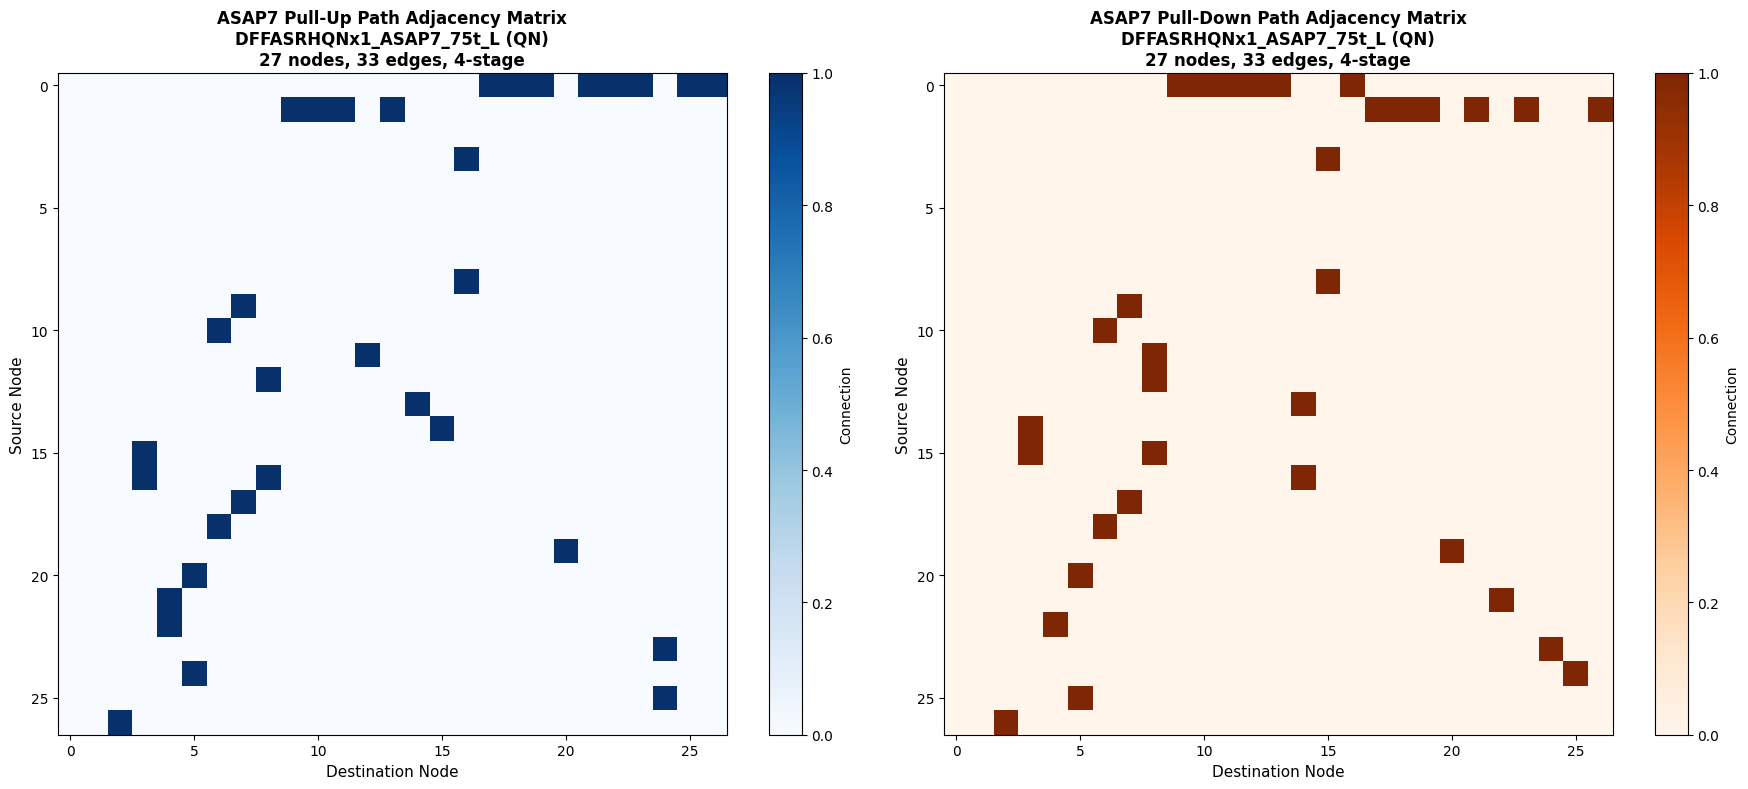

In [ ]:
# Find a cell with multiple stages for visualization
multi_stage_cell = None
for cell_name, cell_data in stage_aware_cache.items():
    for output_name in cell_data['output_nodes']:
        if output_name in cell_data['output_topologies']:
            output_topo = cell_data['output_topologies'][output_name]
            stage_info_up = output_topo['pull_up'].get('stage_info', {})
            stage_info_down = output_topo['pull_down'].get('stage_info', {})
            
            num_up = stage_info_up.get('num_stages', 0)
            if num_up == 0 and 'stage_type' in stage_info_up:
                num_up = 2 if stage_info_up['stage_type'] == 'two_stage' else 1
            
            num_down = stage_info_down.get('num_stages', 0)
            if num_down == 0 and 'stage_type' in stage_info_down:
                num_down = 2 if stage_info_down['stage_type'] == 'two_stage' else 1
            
            if num_up >= 3 or num_down >= 3:
                multi_stage_cell = (cell_name, output_name)
                break
    if multi_stage_cell:
        break

if multi_stage_cell:
    cell_name, output_name = multi_stage_cell
else:
    cell_name = sorted(stage_aware_cache.keys())[0]
    output_name = stage_aware_cache[cell_name]['output_nodes'][0]

cell_cache = stage_aware_cache[cell_name]
output_topo = cell_cache['output_topologies'][output_name]
pull_up = output_topo['pull_up']
pull_down = output_topo['pull_down']

# Get stage counts
num_up = pull_up['stage_info'].get('num_stages', 0)
if num_up == 0 and 'stage_type' in pull_up['stage_info']:
    num_up = 2 if pull_up['stage_info']['stage_type'] == 'two_stage' else 1

num_down = pull_down['stage_info'].get('num_stages', 0)
if num_down == 0 and 'stage_type' in pull_down['stage_info']:
    num_down = 2 if pull_down['stage_info']['stage_type'] == 'two_stage' else 1

print(f"Visualizing: {cell_name} ({output_name})")
print(f"Pull-up: {num_up}-stage")
print(f"Pull-down: {num_down}-stage")

if 'adjacency_matrix' in pull_up and 'adjacency_matrix' in pull_down:
    adj_up = pull_up['adjacency_matrix']
    adj_down = pull_down['adjacency_matrix']
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Pull-up
    im1 = axes[0].imshow(adj_up.numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
    axes[0].set_title(f'ASAP7 Pull-Up Path Adjacency Matrix\n{cell_name} ({output_name})\n'
                     f'{adj_up.shape[0]} nodes, {adj_up.nonzero().shape[0]} edges, {num_up}-stage',
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Destination Node', fontsize=11)
    axes[0].set_ylabel('Source Node', fontsize=11)
    plt.colorbar(im1, ax=axes[0], label='Connection')
    
    if adj_up.shape[0] <= 20:
        axes[0].set_xticks(range(len(pull_up['all_nodes'])))
        axes[0].set_xticklabels(pull_up['all_nodes'], rotation=90, fontsize=8)
        axes[0].set_yticks(range(len(pull_up['all_nodes'])))
        axes[0].set_yticklabels(pull_up['all_nodes'], fontsize=8)
    
    # Pull-down
    im2 = axes[1].imshow(adj_down.numpy(), cmap='Oranges', aspect='auto', interpolation='nearest')
    axes[1].set_title(f'ASAP7 Pull-Down Path Adjacency Matrix\n{cell_name} ({output_name})\n'
                     f'{adj_down.shape[0]} nodes, {adj_down.nonzero().shape[0]} edges, {num_down}-stage',
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Destination Node', fontsize=11)
    axes[1].set_ylabel('Source Node', fontsize=11)
    plt.colorbar(im2, ax=axes[1], label='Connection')
    
    if adj_down.shape[0] <= 20:
        axes[1].set_xticks(range(len(pull_down['all_nodes'])))
        axes[1].set_xticklabels(pull_down['all_nodes'], rotation=90, fontsize=8)
        axes[1].set_yticks(range(len(pull_down['all_nodes'])))
        axes[1].set_yticklabels(pull_down['all_nodes'], fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("No adjacency matrices to visualize!")

## 9. Detailed Cell Analysis (XOR/XNOR)

In [ ]:
# Find XOR or XNOR cells for detailed analysis
xor_cells = [name for name in stage_aware_cache.keys() if 'XOR' in name.upper() or 'XNOR' in name.upper()]

print(f"Found {len(xor_cells)} XOR/XNOR cells")
print("=" * 80)

for cell_name in sorted(xor_cells)[:5]:  # First 5
    cell_data = stage_aware_cache[cell_name]
    
    print(f"\n{cell_name}")
    print("-" * 60)
    
    for output_name in cell_data['output_nodes']:
        if output_name in cell_data['output_topologies']:
            output_topo = cell_data['output_topologies'][output_name]
            
            # Pull-up details
            pull_up = output_topo['pull_up']
            stage_info_up = pull_up.get('stage_info', {})
            num_up = stage_info_up.get('num_stages', 0)
            if num_up == 0 and 'stage_type' in stage_info_up:
                num_up = 2 if stage_info_up['stage_type'] == 'two_stage' else 1
            stages_up = stage_info_up.get('stages', [])
            intermediate_up = stage_info_up.get('intermediate_gates', [])
            widths_up = stage_info_up.get('intermediate_gate_widths', {})
            
            print(f"  {output_name} Pull-up ({num_up}-stage):")
            print(f"    Nodes: {pull_up['all_nodes']}")
            print(f"    Intermediate gates: {intermediate_up}")
            if widths_up:
                print(f"    Gate widths: {widths_up}")
            else:
                print(f"    Gate widths: (runtime fallback from transistor_info)")
            if stages_up:
                for i, stage in enumerate(stages_up):
                    print(f"    Stage {i+1}: trans={stage.get('transistors', [])}, gates={stage.get('gates', [])}")
            else:
                # Legacy format
                for key in sorted(stage_info_up.keys()):
                    if 'transistors' in key.lower():
                        print(f"    {key}: {stage_info_up[key]}")
            
            # Pull-down details
            pull_down = output_topo['pull_down']
            stage_info_down = pull_down.get('stage_info', {})
            num_down = stage_info_down.get('num_stages', 0)
            if num_down == 0 and 'stage_type' in stage_info_down:
                num_down = 2 if stage_info_down['stage_type'] == 'two_stage' else 1
            stages_down = stage_info_down.get('stages', [])
            intermediate_down = stage_info_down.get('intermediate_gates', [])
            widths_down = stage_info_down.get('intermediate_gate_widths', {})
            
            print(f"  {output_name} Pull-down ({num_down}-stage):")
            print(f"    Nodes: {pull_down['all_nodes']}")
            print(f"    Intermediate gates: {intermediate_down}")
            if widths_down:
                print(f"    Gate widths: {widths_down}")
            else:
                print(f"    Gate widths: (runtime fallback from transistor_info)")
            if stages_down:
                for i, stage in enumerate(stages_down):
                    print(f"    Stage {i+1}: trans={stage.get('transistors', [])}, gates={stage.get('gates', [])}")
            else:
                # Legacy format
                for key in sorted(stage_info_down.keys()):
                    if 'transistors' in key.lower():
                        print(f"    {key}: {stage_info_down[key]}")

Found 6 XOR/XNOR cells

XNOR2x1_ASAP7_75t_L
------------------------------------------------------------
  Y Pull-up (2-stage):
    Nodes: ['VDD', 'VSS', 'Y', 'net29', 'MM3', 'MM2', 'MM11', 'MM10', 'MM9']
    Intermediate gates: ['net29']
    Gate widths: {'net29': 0.324}
    Stage 1: trans=['MM3', 'MM2'], gates=[]
    Stage 2: trans=['MM11', 'MM10', 'MM9'], gates=[]
  Y Pull-down (2-stage):
    Nodes: ['VDD', 'VSS', 'Y', 'net29', 'MM0', 'MM1', 'MM4', 'MM6', 'MM5']
    Intermediate gates: ['net29']
    Gate widths: {'net29': 0.324}
    Stage 1: trans=['MM0', 'MM1'], gates=[]
    Stage 2: trans=['MM4', 'MM6', 'MM5'], gates=[]

XNOR2x2_ASAP7_75t_L
------------------------------------------------------------
  Y Pull-up (3-stage):
    Nodes: ['VDD', 'VSS', 'Y', 'net036', 'xor', 'MM3', 'MM2', 'MM11', 'MM10', 'MM9', 'MM12']
    Intermediate gates: ['net036', 'xor']
    Gate widths: {'net036': 0.162, 'xor': 0.324}
    Stage 1: trans=['MM3', 'MM2'], gates=[]
    Stage 2: trans=['MM11', 'MM10'

## 10. Summary Statistics

In [ ]:
print("=" * 100)
print("ASAP7 MULTI-STAGE CACHE VERIFICATION SUMMARY")
print("=" * 100)

# Count cache format types
has_num_stages = 0
has_stages_list = 0
has_intermediate_widths = 0
has_legacy_stage_type = 0
has_5dim_edge_attr = 0
has_3dim_edge_attr = 0
total_paths = 0

for cell_data in stage_aware_cache.values():
    for output_topo in cell_data['output_topologies'].values():
        for path_type in ['pull_up', 'pull_down']:
            path_data = output_topo[path_type]
            stage_info = path_data.get('stage_info', {})
            total_paths += 1
            
            if 'num_stages' in stage_info:
                has_num_stages += 1
            if 'stages' in stage_info:
                has_stages_list += 1
            if 'intermediate_gate_widths' in stage_info:
                has_intermediate_widths += 1
            if 'stage_type' in stage_info:
                has_legacy_stage_type += 1
            
            edge_attr = path_data.get('edge_attr', None)
            if edge_attr is not None:
                if edge_attr.shape[1] == 5:
                    has_5dim_edge_attr += 1
                elif edge_attr.shape[1] == 3:
                    has_3dim_edge_attr += 1

print(f"\nTotal cells: {len(stage_aware_cache)}")
print(f"Total paths: {total_paths}")

print(f"\nFormat Support:")
print(f"   Paths with num_stages (multi-stage): {has_num_stages}/{total_paths} ({has_num_stages/total_paths*100:.1f}%)")
print(f"   Paths with stages list: {has_stages_list}/{total_paths} ({has_stages_list/total_paths*100:.1f}%)")
print(f"   Paths with stage_type (legacy): {has_legacy_stage_type}/{total_paths} ({has_legacy_stage_type/total_paths*100:.1f}%)")
print(f"   Paths with intermediate_gate_widths: {has_intermediate_widths}/{total_paths} ({has_intermediate_widths/total_paths*100:.1f}%)")

print(f"\nEdge Attribute Dimensions:")
print(f"   5-dim (multi-stage): {has_5dim_edge_attr}/{total_paths} ({has_5dim_edge_attr/total_paths*100:.1f}%)")
print(f"   3-dim (legacy): {has_3dim_edge_attr}/{total_paths} ({has_3dim_edge_attr/total_paths*100:.1f}%)")

print(f"\nStage Distribution:")
print(f"   Pull-up: {dict(Counter(pull_up_stages))}")
print(f"   Pull-down: {dict(Counter(pull_down_stages))}")

print(f"\n{'=' * 100}")
if has_num_stages == total_paths and has_5dim_edge_attr == total_paths:
    print("VERIFICATION PASSED: Multi-stage format is properly applied!")
elif has_num_stages > 0:
    print("PARTIAL: Some paths have multi-stage format, some may have legacy format.")
elif has_legacy_stage_type == total_paths:
    print("LEGACY FORMAT: Cache uses old one_stage/two_stage format.")
    print("               Run precompute_stage_aware_topology.py to update.")
else:
    print("UNKNOWN FORMAT: Check cache structure.")
print("=" * 100)

ASAP7 MULTI-STAGE CACHE VERIFICATION SUMMARY

Total cells: 160
Total paths: 324

Format Support:
   Paths with num_stages (multi-stage): 324/324 (100.0%)
   Paths with stages list: 324/324 (100.0%)
   Paths with stage_type (legacy): 324/324 (100.0%)
   Paths with intermediate_gate_widths: 150/324 (46.3%)

Edge Attribute Dimensions:
   5-dim (multi-stage): 324/324 (100.0%)
   3-dim (legacy): 0/324 (0.0%)

Stage Distribution:
   Pull-up: {2: 72, 1: 87, 4: 1, 3: 2}
   Pull-down: {2: 72, 1: 87, 4: 1, 3: 2}

VERIFICATION PASSED: Multi-stage format is properly applied!


## 11. Available ASAP7 Cache Files

In [ ]:
# List all available ASAP7 cache files
cache_dir = Path("/home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache")

print("Available ASAP7 Topology Cache Files:")
print("=" * 80)

asap7_caches = sorted([f for f in cache_dir.glob("*asap7*.pth")])
if asap7_caches:
    for cache_file in asap7_caches:
        size_mb = cache_file.stat().st_size / (1024 * 1024)
        print(f"   {cache_file.name:<60s} ({size_mb:.2f} MB)")
else:
    print("   No ASAP7 cache files found.")

print("\nAvailable TSMC Topology Cache Files:")
print("=" * 80)

tsmc_caches = sorted(cache_dir.glob("*tsmc*.pth"))
if tsmc_caches:
    for cache_file in tsmc_caches:
        size_mb = cache_file.stat().st_size / (1024 * 1024)
        print(f"   {cache_file.name:<60s} ({size_mb:.2f} MB)")
else:
    print("   No TSMC cache files found.")

Available ASAP7 Topology Cache Files:
   cell_topology_cache_asap7sc7p5t_28_L.pth                     (0.93 MB)
   cell_topology_cache_asap7sc7p5t_28_R.pth                     (0.93 MB)
   cell_topology_cache_asap7sc7p5t_28_SL.pth                    (0.93 MB)
   cell_topology_cache_asap7sc7p5t_28_SRAM.pth                  (0.93 MB)
   full_graph_topology_cache_asap7sc7p5t_28_L.pth               (0.93 MB)
   stage_aware_topology_cache_asap7sc7p5t_28_L.pth              (1.35 MB)

Available TSMC Topology Cache Files:
   cell_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical.pth (0.51 MB)
   cell_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical_weighted.pth (0.73 MB)
   full_graph_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical.pth (0.51 MB)
   full_graph_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical_weighted.pth (0.73 MB)
   stage_aware_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical.pth (0.88 MB)
   stage_aware_topology_cache_tsm